# Experiment 01 - Distance to Linear Regime

Goal:
Estimate how far a dataset is from ideal linear coherence using spectral structure. The goal is to explore how much of a dataset's total variance is not explained by the first k prinicipal componenets.

Datasets:
Synthetically generated datasets representing known geometric outcomes - Perfect line, circle, Gaussian noise.
Data will be mean centred and standardized, in order for the probe to be scale invariant.




In [2]:
# Dependencies

import numpy as np
from numpy.typing import NDArray
import pandas as pd

In [7]:
# Generate synthetic datasets (Perfect Line, Perfect Line with Noise, 2D plane, Circle, Gaussian Noise)

# Set seed for reproducibility
np.random.seed(42)

# Generate perfect line

def generate_line_df(n: int, d: int) -> NDArray[np.float64]:

    """
    Takes n samples, d features and generates a perfectly linear array with rank 1.

    :param n: First integer
    :param d: Second integer
    :return line_df: d dimensional array with n rows
    """

    v = np.random.uniform(1, 50, size=d)

    t = np.random.uniform(-1, 1, size=n)

    line_df = np.outer(t, v)

    return line_df

def generate_gaussian_noise_df(n: int, d: int) -> NDArray[np.float64]:

    
    """
    Takes n samples, d features and generates a noisy dataset of distribution (0,1)

    :param n: First integer
    :param d: Second integer
    :return noise_df: d dimensional array with n rows
    """

    noise_df = np.random.normal(0, 1 , size=(n, d))

    return noise_df

def generate_plane_df(n: int, d: int) -> NDArray[np.float64]:

    
    """
    Takes n samples, d features and generates a dataset with 2 prinicipal directions (plane) in d-space

    :param n: First integer
    :param d: Second integer
    :return plane_df: d dimensional array with n rows
    """

    # Generate latent scalars
    ai = np.random.uniform(-1, 1, size=n)
    bi = np.random.uniform(-1, 1, size=n)

    # Generate vectors
    v1 = np.random.uniform(-1, 1, size=d)
    v2 = np.random.uniform(-1, 1, size=d)

    aiv = np.outer(ai, v1)
    biv = np.outer(bi, v2)

    plane_df = aiv + biv

    return plane_df

def generate_circle_df(n: int, d: int) -> NDArray[np.float64]:

    """
    Takes n samples, d features and generates a circular manifold embedded in d-dimensional space

    :param n: First integer
    :param d: Second integer
    :return circle_df: d dimensional array with n rows
    """
        
    a = np.random.uniform(0, 2*np.pi, size=n)

    v1 = np.random.uniform(-1, 1, size=d)
    v2 = np.random.uniform(-1, 1, size=d)

    av1 = np.outer(np.cos(a), v1)
    av2 = np.outer(np.sin(a), v2)

    circle_df = av1 + av2
    return circle_df
    


def add_noise(scalar: float, df: NDArray[np.float64]) -> NDArray[np.float64]:

    """
    Takes n samples, d features, df

    :param scalar: Scalar for noise control, percentage
    :param df: array with n samples and d features
    :return df_with_noise: n*d array with added noise
    
    """

    n, d = df.shape

    df_std = np.std(df, axis=0, ddof=0)

    Z = np.random.normal(0, 1 , size=(n, d))

    E = scalar * df_std * Z

    df_with_noise = E + df

    return df_with_noise





In [8]:

# Set n sample and d features
n = 1000
d = 50

# Generate datasets
line_df = generate_line_df(n, d)
line_with_noise = add_noise(scalar=0.01, df=line_df)
plane_df = generate_plane_df(n, d)
circle_df = generate_circle_df(n, d)
noise_df = generate_gaussian_noise_df(n, d)

# Rank expectations
print(f"Perfect line expects rank 1, got {np.linalg.matrix_rank(line_df)}")
print(f"Plane expects rank 2, got {np.linalg.matrix_rank(plane_df)}")
print(f"Circle expects rank 2, got {np.linalg.matrix_rank(circle_df)}")
print(f"Line with noise expects rank ~{d}, got {np.linalg.matrix_rank(line_with_noise)}")
print(f"Gaussian noise expects rank ~{d}, got {np.linalg.matrix_rank(noise_df)}")

Perfect line expects rank 1, got 1
Plane expects rank 2, got 2
Circle expects rank 2, got 2
Line with noise expects rank ~50, got 50
Gaussian noise expects rank ~50, got 50


The above displays that rank is a binary property and becomes unstable even under small pertubations, whereas spectral residual measures preserve graded information about structural coherence.

In [9]:
# Functionality for delta_lin. Data is mean-centered and standardized, singular values are squared for energy.

def lin_spectrum(X: NDArray[np.float64]) -> NDArray[np.float64]:

    """ 
    lin_spectrum takes an n*d array, mean centers and standardizing it so it is scale invariant. Performs SVD and returns squared spectrum for energy.

    :param X: array
    :return S_squared: array

    """
    # Mean centre and standardize
    X_centre = (X - np.mean(X, axis=0))
    X_sigma = np.std(X, axis=0, ddof=0)

    # Replace std of 0 with 1
    X_sigma[X_sigma == 0] = 1

    X_scaled = X_centre / X_sigma

    # Compute SVD
    U, S, vt = np.linalg.svd(X_scaled, full_matrices=False)

    # Square to get variance
    S_squared = S*S

    return S_squared

def delta_lin(S_squared: NDArray[np.float64], k: int) -> float:
 
    """ 
    Takes S_squared and k as input, and returns the spectral residue remaining after k ranks.

    :param S_squared: array
    :param k: int
    :return delta_lin_k: float

    """

    if k < 1:
        raise ValueError(f"k must be 1 or greater")
    
    if k > len(S_squared):
        raise ValueError(f"k must be less than or equal to {len(S_squared)}")
     
    total_energy = np.sum(S_squared)
    first_k_energy = np.sum(S_squared[:k])

    delta_lin_k = 1 - (first_k_energy / total_energy)

    return delta_lin_k


def generate_delta_lin_curve(S_squared: NDArray[np.float64] ) -> NDArray[np.float64]:

    """ 
    Generates delta curve for 1 : k

    :param S_squared: array
    :return delta_values: NDArray

    """
    
    cumulative = np.cumsum(S_squared)
    delta_values = 1 - (cumulative / cumulative[-1])

    return delta_values
        


In [17]:
line_spectrum = lin_spectrum(line_df)
delta_line = generate_delta_lin_curve(line_spectrum)

plane_spectrum = lin_spectrum(plane_df)
delta_plane = generate_delta_lin_curve(plane_spectrum)

circle_spectrum = lin_spectrum(circle_df)
delta_circle = generate_delta_lin_curve(circle_spectrum)

gaussian_noise_spectrum = lin_spectrum(noise_df)
delta_gaussian_noise = generate_delta_lin_curve(gaussian_noise_spectrum)

line_with_noise_spectrum = lin_spectrum(line_with_noise)
delta_line_with_noise = generate_delta_lin_curve(line_with_noise_spectrum)

The expectation is that the synthetic datasets that have been produced can reliably have the remainder of variance in their spectral tail after k ranks estimated in a stable manner. The expectations of results are as follows:

Perfectly linear dataset in d dimensions:
delta_lin(1) ≈ 0

A 2-dimensional plane:
delta_lin(1) ≈ 0.5, delta_lin(2) ≈ 0

A 2-dimensional circular manifold in d dimensions:
delta_lin(1) ≈ 0.5, delta_lin(2) ≈ 0

Gaussian Noise:
Variance should be distributed somewhat evenly across many directions, producing a slow spectral decay and realtively large residual values for small k.

A perfectly linear dataset with noise:
The spectrum should show one large, principal direction of dominance with a slow spectral tail. This displays that SVD can be sensitive to noise when computing variance along prinicpal axes.


The most interesting comparison will be between the 2-D plane, and the circular manifold, since both lie in the same subspace but differ in their intrinsic geometry. This experiment should therefore show that the linear spectral probe detects subspace dimensionality but does not capture nonlinear manifold structure.

In [27]:
# Linear dataset
print(f"Linear dataset: δ_lin(1) expects ≈ 0, got {delta_lin(line_spectrum, 1)}")

# Plane
print(f"Plane dataset: δ_lin(1) expects ≈ 0.5, got {delta_lin(plane_spectrum, 1)}, δ_lin(2) expects ≈ 0, got {delta_lin(plane_spectrum, 2)}")

# Circular manifold
print(f"2-D manifold dataset: δ_lin(1) expects ≈ 0.5, got {delta_lin(circle_spectrum, 1)}, δ_lin(2) expects ≈ 0, got {delta_lin(circle_spectrum, 2)}")

# Gaussian Noise - Slow tail expected
print(f"Gaussian Noise: δ_lin(d-1) expects > 0, got {delta_lin(gaussian_noise_spectrum, d-1)}")

# Line with noise - Small, low tail expected
print(f"Linear with noise dataset: δ_lin(1) expects small value, got {delta_lin(line_with_noise_spectrum, 1)}, δ_lin(d-1) expects > 0, got {delta_lin(line_with_noise_spectrum, d-1)}")

Linear dataset: δ_lin(1) expects ≈ 0, got 0.0
Plane dataset: δ_lin(1) expects ≈ 0.5, got 0.452767857919229, δ_lin(2) expects ≈ 0, got 0.0
2-D manifold dataset: δ_lin(1) expects ≈ 0.5, got 0.49951282390331264, δ_lin(2) expects ≈ 0, got 0.0
Gaussian Noise: δ_lin(d-1) expects > 0, got 0.012352461415345073
Linear with noise dataset: δ_lin(1) expects small value, got 9.785219907454401e-05, δ_lin(d-1) expects > 0, got 1.1966632694759838e-06


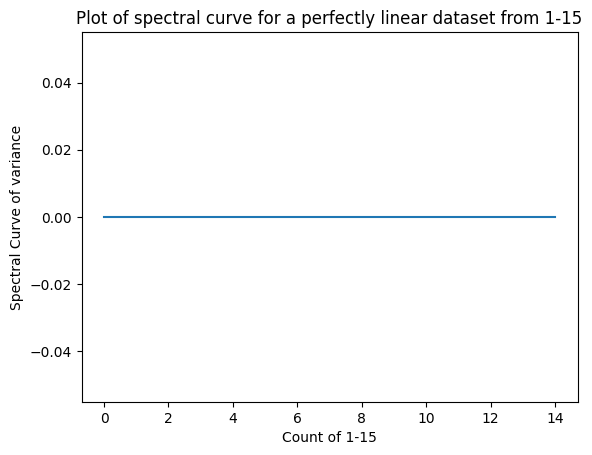

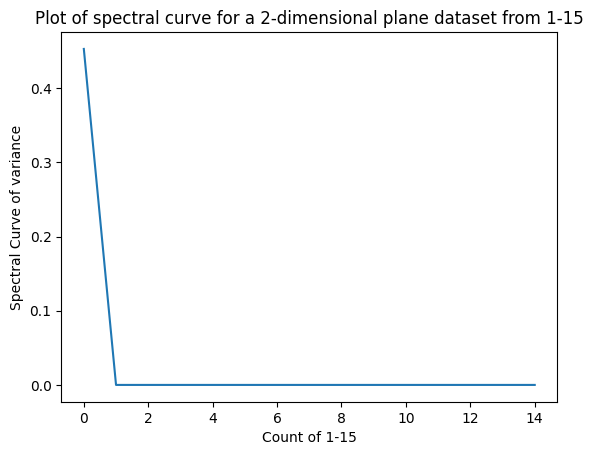

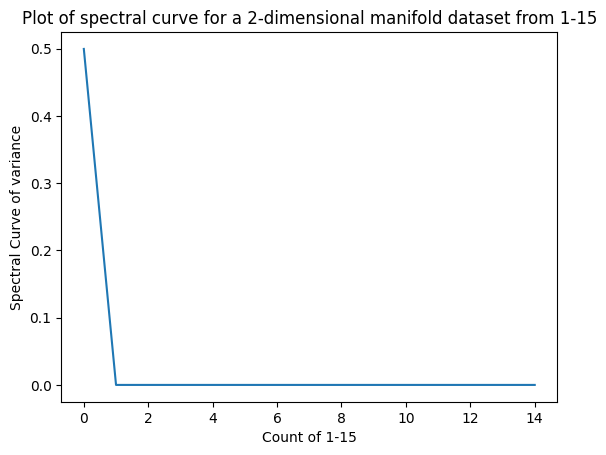

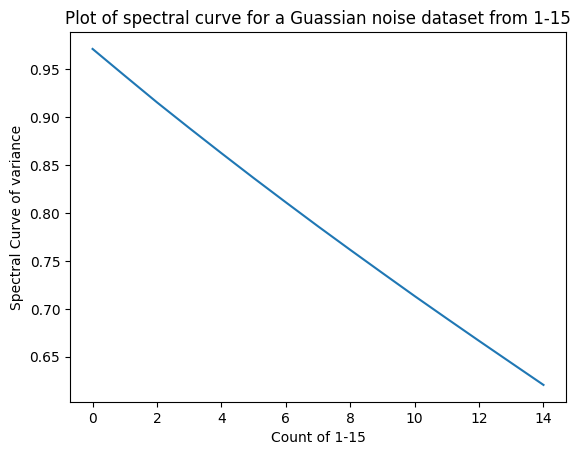

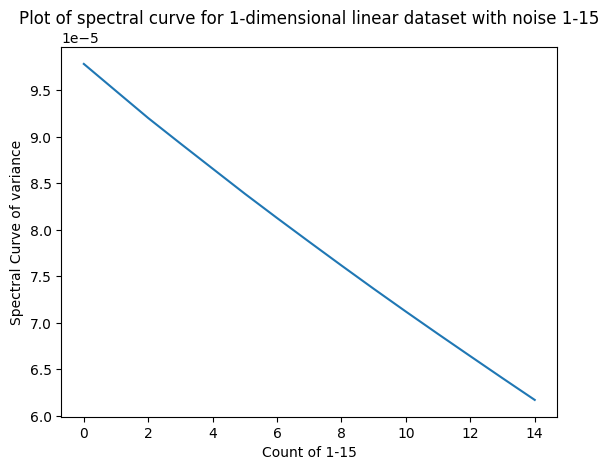

In [35]:
import matplotlib.pyplot as plt

# Values for 1-15. Limiting k to display spectral curve more cleanly
k = 15
k_values = range(0, k)

# Line_df spectral curve
plt.plot(k_values, delta_line[:k])
plt.title(f"Plot of spectral curve for a perfectly linear dataset from 1-{k}")
plt.xlabel(f"Count of 1-{k}")
plt.ylabel("Spectral Curve of variance")
plt.show()

# plane_df spectral curve
plt.plot(k_values, delta_plane[:k])
plt.title(f"Plot of spectral curve for a 2-dimensional plane dataset from 1-{k}")
plt.xlabel(f"Count of 1-{k}")
plt.ylabel("Spectral Curve of variance")
plt.show()

# cirlce_df spectral curve
plt.plot(k_values, delta_circle[:k])
plt.title(f"Plot of spectral curve for a 2-dimensional manifold dataset from 1-{k}")
plt.xlabel(f"Count of 1-{k}")
plt.ylabel("Spectral Curve of variance")
plt.show()

# Gaussian Noise_df spectral curve
plt.plot(k_values, delta_gaussian_noise[:k])
plt.title(f"Plot of spectral curve for a Guassian noise dataset from 1-{k}")
plt.xlabel(f"Count of 1-{k}")
plt.ylabel("Spectral Curve of variance")
plt.show()

# line_with_noise_df spectral curve
plt.plot(k_values, delta_line_with_noise[:k])
plt.title(f"Plot of spectral curve for 1-dimensional linear dataset with noise 1-{k}")
plt.xlabel(f"Count of 1-{k}")
plt.ylabel("Spectral Curve of variance")
plt.show()

